In [271]:
import numpy as np
from scipy import constants as cs
from scipy import signal
import sympy
from dataclasses import dataclass
from typing import Union, Callable
from IPython.display import display

In [272]:
Scalar = Union[float, int]
Field  = Union[Scalar, Callable[[np.ndarray], np.ndarray]]

@dataclass
class Drone:
    name: str
    N: int
    L_1: float
    L_2: float
    f_rot: float

@dataclass
class Radar:
    λ: float
    f_c: float

@dataclass
class Context:
    R:       Field
    V_rad:   Field
    θ:       Field
    Φ_p:     Field
    A_r:     Field
    t_start: float
    t_stop:  float
    dt:      float

    def resolve(self, field, t: np.ndarray) -> np.ndarray:
        return field(t) if callable(field) else np.full_like(t, field, dtype=float)

In [273]:
λ = 0.02998
default_radar = Radar(
    λ = λ,
    f_c = cs.c/λ
)

djimavicair2 = Drone(
    name="DJI_Mavic_Air_2",
    N=2,
    L_1=0.005,
    L_2=0.07,
    f_rot=91.66
)

djimavicair2 = Drone(
    name="DJI_Mavic_Air_2",
    N=2,
    L_1=0.005,
    L_2=0.07,
    f_rot=91.66,
)

djimavicmini = Drone(
    name="DJI_Mavic_Mini",
    N=2,
    L_1=0.005,
    L_2=0.035,
    f_rot=160,
)

djimatrice300rtk = Drone(
    name="DJI_Matrice_300_RTK",
    N=2,
    L_1=0.05,
    L_2=0.2665,
    f_rot=70,
)

parrotdisco = Drone(
    name="Parrot_Disco",
    N=2,
    L_1=0.01,
    L_2=0.104,
    f_rot=40,
)

djiphantom4 = Drone(
    name="DJI_Phantom_4",
    N=2,
    L_1=0.006,
    L_2=0.05,
    f_rot=116,
)

class_map = ["DJI_Matrice_300_RTK", "DJI_Mavic_Air_2",
             "DJI_Mavic_Mini", "DJI_Phantom_4", "Parrot_Disco"]

drones = [djimatrice300rtk, djimavicair2, djimavicmini, djiphantom4, parrotdisco]

In [274]:
class BaseNoiseModel(): # To be integrated with SyntheticSignalGenerator
    def __init__(self):
        self.noise_model.params_set_flag =  False
        pass
    def apply_noise(self):
        pass
    def set_parameters(self, params):
        pass

In [293]:
class SyntheticSignalGenerator:
    def __init__(self, drone, radar, noise_model=None):
        self.drone = drone
        self.radar = radar
        self.noise_model = noise_model

        self.base_Psi_f = self._prepare_Psi_functions()

    def _prepare_sympy_Psi_function(self):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad, L_1, L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        alpha = sympy.sin(sympy.Abs(theta) + Phi_p) + sympy.sin(sympy.Abs(theta) - Phi_p)
        beta  = sympy.sign(theta) * alpha
        Omega_n = 2 * sympy.pi * (f_rot * t + n / N)
        gamma_n = 4 * sympy.pi / lamb * sympy.cos(theta) * sympy.sin(Omega_n)

        first_part = A_r * sympy.exp(sympy.I*(2*sympy.pi*f_c*t - 4*sympy.pi/lamb*(R+V_rad*t)))

        # alpha, beta, Omega_n, gamma_n = sympy.symbols("α β Ω_n γ_n") # Just for verifying the equation

        element_second_part = (alpha + beta * sympy.cos(Omega_n)) * sympy.exp(-sympy.I*(L_1+L_2)/2) * sympy.sinc((L_2-L_1)/2*gamma_n)

        Psi = first_part + sympy.Sum(element_second_part, (n,1,N))

        # display(Phi)
        return Psi

    def _partially_substitute_Psi(self, Psi):
        theta, Phi_p, f_rot, t, lamb, A_r, f_c, R, V_rad, L_1, L_2 = sympy.symbols("θ Φ_p f_rot t λ A_r f_c, R, V_rad L_1 L_2")
        n, N = sympy.symbols("n N", integer=True, positive=True)

        subs = {
            f_rot: self.drone.f_rot,
            N:     self.drone.N,
            L_1:   self.drone.L_1,
            L_2:   self.drone.L_2,
            lamb:  self.radar.λ,
            f_c:   self.radar.f_c,

        }
        Psi_sub = Psi.subs(subs).doit()
        # display(Psi_sub)

        return Psi_sub

    def _prepare_Psi_functions(self):
        full_Psi = self._prepare_sympy_Psi_function()
        partially_substituted_Psi = self._partially_substitute_Psi(full_Psi)
        return partially_substituted_Psi

    def _lambidfy_Psi(self):
        t, R, V_rad, theta, Phi_p, A_r = sympy.symbols("t R V_rad θ Φ_p A_r")
        args = [t, A_r, Phi_p, R, V_rad, theta]
        return sympy.lambdify(args, self.base_Psi_f, "numpy")

    def set_noise_parameters(self, params):
        self.noise_model.set_parameters(params) #TODO implement
        pass

    def generate_signal(self, context):
        if not isinstance(context, Context):
            raise ValueError("Provided context is not of Context class")
        if (self.noise_model is not None) and self.noise_model.params_set_flag == False:
            raise AttributeError("The noise_model parameters were not set. Please set them with set_noise_parameters(params)")

        Psi_f = self._lambidfy_Psi()
        t_array = np.arange(context.t_start,context.t_stop,context.dt)

        if self.noise_model is None:
            R     = context.resolve(context.R,     t_array)
            V_rad = context.resolve(context.V_rad, t_array)
            θ     = context.resolve(context.θ,     t_array)
            Φ_p   = context.resolve(context.Φ_p,   t_array)
            A_r   = context.resolve(context.A_r,   t_array)
            signal = Psi_f(t_array, R, V_rad, θ, Φ_p, A_r)

        else:
            signal = []
            for t in t_array:
                R     = context.resolve(context.R,     t)
                V_rad = context.resolve(context.V_rad, t)
                θ     = context.resolve(context.θ,     t)
                Φ_p   = context.resolve(context.Φ_p,   t)
                A_r   = context.resolve(context.A_r,   t)
                params = {
                    "t": t
                }
                signal.append(self.noise_model.apply_noise(Psi_f(t_array, R, V_rad, θ, Φ_p, A_r), params))
            signal = np.array(signal)
        return t_array, signal

In [294]:
synt_signal_generator = SyntheticSignalGenerator(djiphantom4, default_radar)

In [312]:
context = Context(
    # R=lambda t: 200 - 10*t,
    R=200,
    V_rad=10,
    θ=np.pi/2,
    Φ_p=np.pi/2,
    A_r=1,
    t_start=0,
    t_stop=1,
    dt=0.001
)

x,y = synt_signal_generator.generate_signal(context)

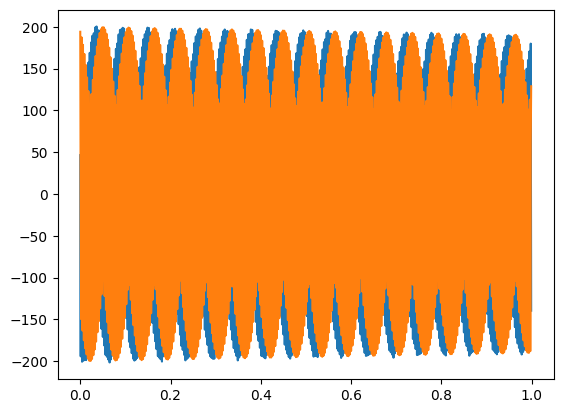

In [313]:
from matplotlib import pyplot as plt
plt.plot(x,y.real)
plt.plot(x,y.imag)